In [1]:
# Importando a biblioteca que organiza dados em tabelas
import pandas as pd

print("Ferramenta Pandas carregada com sucesso!")

Ferramenta Pandas carregada com sucesso!


In [2]:
# 1. Definimos o endereço de onde os dados estão
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'

# 2. Mandamos o Pandas ler esse arquivo JSON e guardar numa variável chamada 'df' (de DataFrame/Tabela)
df = pd.read_json(url)

# 3. Pedimos para mostrar as 5 primeiras linhas para ver se deu certo
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
# Vamos transformar os dados da coluna 'customer' em várias colunas novas
df_customer = pd.json_normalize(df['customer'])

# Vamos ver como ficou essa parte separada
df_customer.head()

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3


In [4]:
# Abrindo a caixa de informações de telefone
df_phone = pd.json_normalize(df['phone'])

# Abrindo a caixa de informações de internet
df_internet = pd.json_normalize(df['internet'])

# Abrindo a caixa de informações da conta
df_account = pd.json_normalize(df['account'])

print("Todas as informações foram descompactadas!")

Todas as informações foram descompactadas!


In [5]:
# Juntando todas as partes em um novo DataFrame chamado 'df_final'
# Começamos com as colunas ID e Churn, e vamos 'colando' as outras ao lado
df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Vendo o resultado da nossa super tabela
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
# Esse comando mostra o tipo de cada coluna e se existem valores vazios
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [7]:
# Convertendo a coluna Charges.Total para número
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# Verificando se agora temos valores nulos após a conversão forçada
print(df_final['Charges.Total'].isnull().sum())

11


In [8]:
# Removendo as linhas que possuem o valor Charges.Total vazio (nulo)
df_final.dropna(subset=['Charges.Total'], inplace=True)

# Verificando se agora o total de linhas faz sentido (deve ser 7256)
print(f"Total de linhas agora: {len(df_final)}")

Total de linhas agora: 7256


In [9]:
# Mostra um resumo estatístico das colunas numéricas
df_final.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7256.0000,7256.000000,7256.000000,7256.000000
mean,0.1629,32.395535,64.755423,2280.634213
std,0.3693,24.558067,30.125739,2268.632997
min,0.0000,1.000000,18.250000,18.800000
25%,0.0000,9.000000,35.450000,400.225000
50%,0.0000,29.000000,70.300000,1391.000000
75%,0.0000,55.000000,89.900000,3785.300000
max,1.0000,72.000000,118.750000,8684.800000


In [10]:
# Criando uma nova coluna chamada 'Churn_Numeric'
# Onde 'Yes' vira 1 e 'No' vira 0
df_final['Churn_Numeric'] = df_final['Churn'].map({'Yes': 1, 'No': 0})

# Vamos ver a porcentagem real de evasão na empresa
taxa_evasao = df_final['Churn_Numeric'].mean() * 100
print(f"A taxa de evasão (Churn) atual da Telecom X é de: {taxa_evasao:.2f}%")

A taxa de evasão (Churn) atual da Telecom X é de: 26.58%


/tmp/ipython-input-173/4181409752.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_final, palette='viridis')


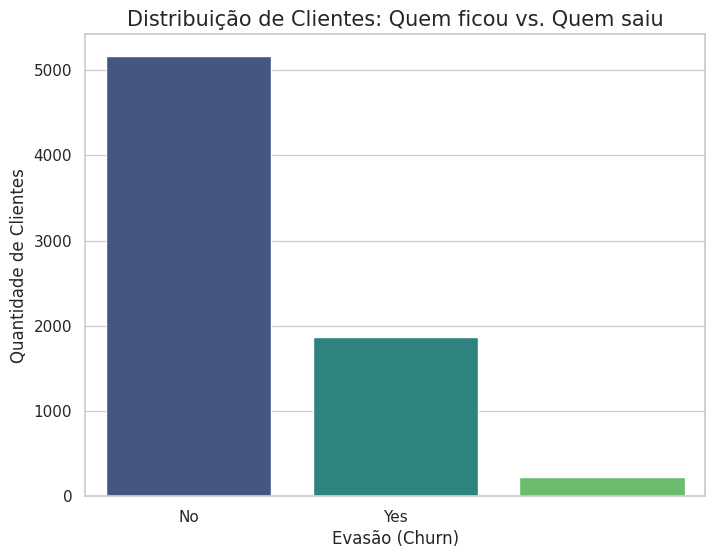

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o estilo do gráfico
sns.set_theme(style="whitegrid")

# Criando o gráfico de contagem para a coluna Churn
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Churn', data=df_final, palette='viridis')

# Adicionando título e nomes nos eixos
plt.title('Distribuição de Clientes: Quem ficou vs. Quem saiu', fontsize=15)
plt.xlabel('Evasão (Churn)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

plt.show()

/tmp/ipython-input-173/1693583111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Monthly', data=df_final, palette='magma')


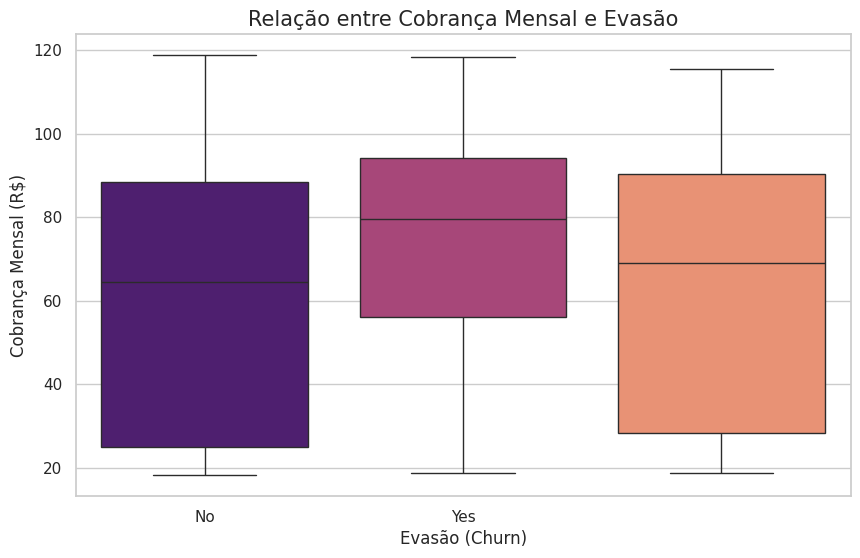

In [12]:
# Criando um gráfico de caixa (boxplot) para comparar preços mensais
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Charges.Monthly', data=df_final, palette='magma')

plt.title('Relação entre Cobrança Mensal e Evasão', fontsize=15)
plt.xlabel('Evasão (Churn)', fontsize=12)
plt.ylabel('Cobrança Mensal (R$)', fontsize=12)

plt.show()

/tmp/ipython-input-173/321793948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_final, palette='coolwarm')


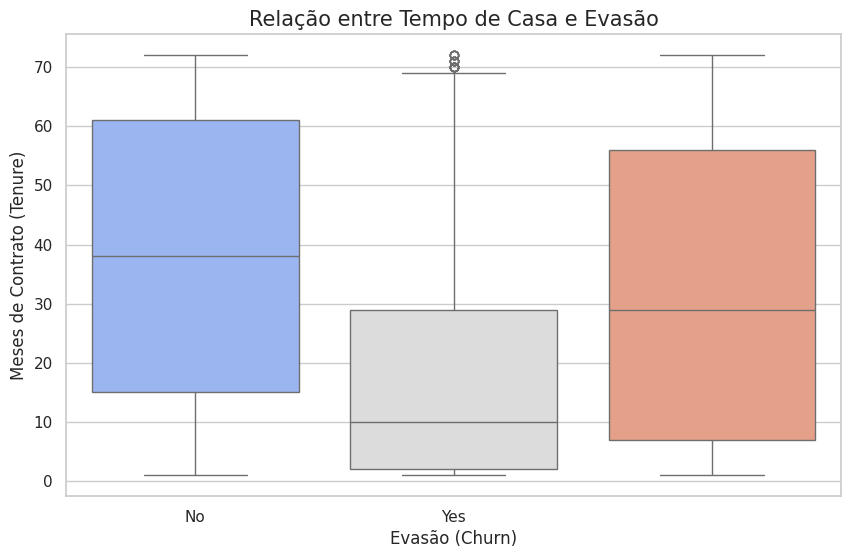

In [13]:
# Comparando o tempo de casa (tenure) com a evasão
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df_final, palette='coolwarm')

plt.title('Relação entre Tempo de Casa e Evasão', fontsize=15)
plt.xlabel('Evasão (Churn)', fontsize=12)
plt.ylabel('Meses de Contrato (Tenure)', fontsize=12)

plt.show()